# Домашнє завдання: Логістична регресія та SVM
У цій роботі ми побудуємо та порівняємо три моделі класифікації: **Логістичну регресію**, **Лінійний SVM** та **SVM з ядром RBF**. 
Замість стандартного набору даних про рак, ми використаємо датасет **Pima Indians Diabetes** для класифікації ризику діабету.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# датасет напряму з онлайн-репозиторію
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

print(f"Розмір датасету: {df.shape}")
print(df.head())

Розмір датасету: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## Підготовка даних
Розділимо дані на ознаки (X) та цільову змінну (y), а також проведемо поділ на навчальну та тестову вибірки.

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=17, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Навчальна вибірка: {X_train_scaled.shape}")
print(f"Тестова вибірка: {X_test_scaled.shape}")

Навчальна вибірка: (576, 8)
Тестова вибірка: (192, 8)


## Навчання моделей
Створимо три різні конфігурації моделей для порівняння.

In [ ]:
algorithms = {
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=17),
    "SVM Linear": SVC(kernel='linear', probability=True, random_state=17),
    "SVM RBF": SVC(kernel='rbf', probability=True, random_state=17)
}

def get_metrics(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred)
    }, y_pred

perf_results = {}
all_preds = {}

for name, model in algorithms.items():
    metrics, preds = get_metrics(model, X_train_scaled, X_test_scaled, y_train, y_test)
    perf_results[name] = metrics
    all_preds[name] = preds

results_df = pd.DataFrame(perf_results).T
results_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.791667,0.728814,0.641791,0.682540
SVM Linear,0.791667,0.728814,0.641791,0.682540
SVM RBF,0.770833,0.682540,0.641791,0.661538


## Візуалізація результатів
Порівняємо точність та F1-міру моделей за допомогою графіків.

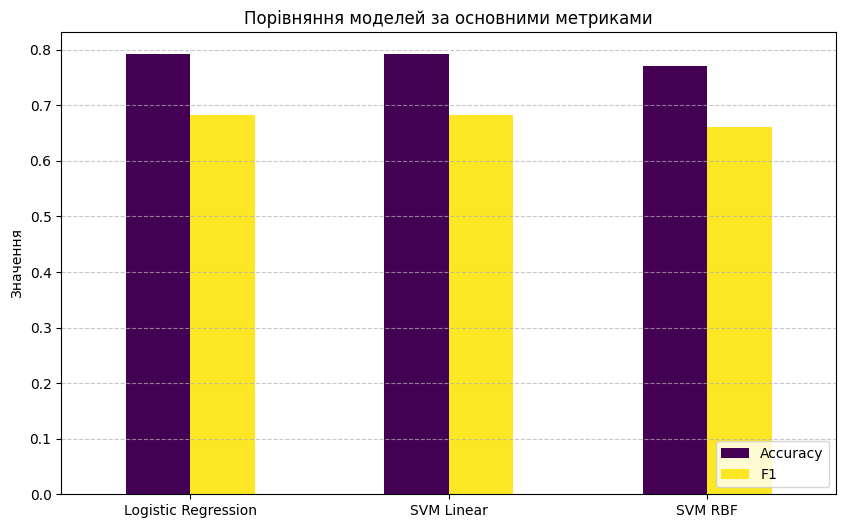

In [5]:
results_df[['Accuracy', 'F1']].plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Порівняння моделей за основними метриками")
plt.ylabel("Значення")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Матриці помилок (Confusion Matrices)
Подивимось, які помилки (першого чи другого роду) частіше роблять наші класифікатори.

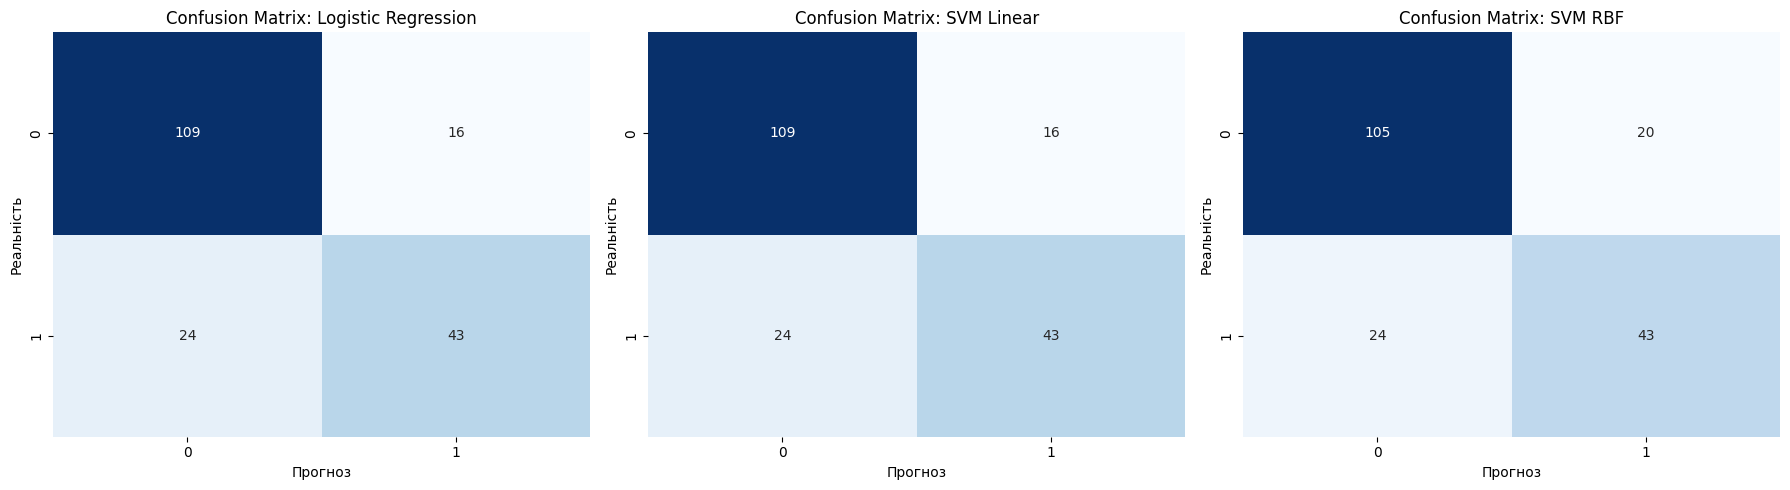

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, preds) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Прогноз")
    axes[i].set_ylabel("Реальність")

plt.tight_layout()
plt.show()

## Фінальний звіт та висновки

In [7]:
for name, preds in all_preds.items():
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, preds))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       125
           1       0.73      0.64      0.68        67

    accuracy                           0.79       192
   macro avg       0.77      0.76      0.76       192
weighted avg       0.79      0.79      0.79       192

--- SVM Linear Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       125
           1       0.73      0.64      0.68        67

    accuracy                           0.79       192
   macro avg       0.77      0.76      0.76       192
weighted avg       0.79      0.79      0.79       192

--- SVM RBF Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       125
           1       0.68      0.64      0.66        67

    accuracy                           0.77       192